In [1]:
import os
import warnings
import pickle

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import shuffle

from catboost import CatBoostClassifier

from cstarters.ml_utils import avg, load_dataset, featurize_alignment, confusion_matrix_plot, plot_permutation_importances, plot_feature_importances, stdev_accuracy

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="sklearn"
)


random_seed = 2

In [2]:
data_dir = "../../data"
out_dir = "../../out"

In [3]:
df = load_dataset(path = os.path.join(data_dir, "cstarters_dataset.csv"))

aa_properties = {
    'WOLS870101': [924, 932, 944],
    'FAUJ880109': [991],
    'TSAJ990101': [814],
    'CHOP780203': [936, 818],
    'NEU1': [936],
    'NEU2': [98],
}

df = featurize_alignment(df, aa_properties)
df = df.dropna(subset=["starter_beta_hydroxylation"])
df = df[~df["starter_beta_hydroxylation"].isin(["unknown", "_not_elligible", "LCFA"])]
ml_df_full = df.drop(columns=["starter_category"])
ml_df_full = ml_df_full.drop(columns=['ncbi_organism_genus'])
ml_df_train, ml_df_test = train_test_split(ml_df_full, test_size = 0.2, stratify = df['starter_beta_hydroxylation'], random_state = random_seed)

y_train = ml_df_train['starter_beta_hydroxylation']
X_train = ml_df_train.drop(columns=['cs_accession', 'starter_beta_hydroxylation'])
X_train, y_train = shuffle(X_train, y_train, random_state=random_seed)

y_test = ml_df_test['starter_beta_hydroxylation']
X_test = ml_df_test.drop(columns=['cs_accession', 'starter_beta_hydroxylation'])
X_test, y_test = shuffle(X_test, y_test, random_state=random_seed)

y_full = ml_df_full['starter_beta_hydroxylation']
X_full = ml_df_full.drop(columns=['cs_accession', 'starter_beta_hydroxylation'])
X_full, y_full = shuffle(X_full, y_full, random_state=random_seed)


# Train

[0.68421053 0.52631579 0.63157895 0.68421053 0.66666667] avg: 0.6385964912280702


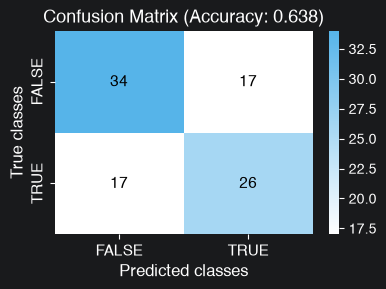

In [4]:
# RF train
rf_params = dict(
    class_weight='balanced',
    ccp_alpha=0.015,
    max_depth=5,
    min_samples_leaf=3,
    max_leaf_nodes=6,
    min_samples_split=5,
    n_estimators=100,
    max_features="log2",
    random_state=random_seed
)
model = RandomForestClassifier(**rf_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"])

[0.84210526 0.84210526 0.68421053 0.78947368 0.77777778] avg: 0.7871345029239766


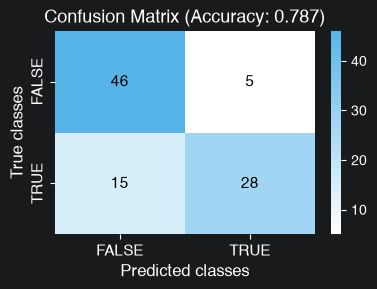

In [5]:
# SVM train
svm_params = dict(
    class_weight='balanced', 
    C=1, 
    degree=2, 
    gamma='auto', 
    kernel='rbf'
)
svm_params = dict(
    probability=True,
    C = 0.1, 
    class_weight='balanced'
)

model = svm.SVC(**svm_params)


cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"])

[0.63157895 0.73684211 0.73684211 0.73684211 0.66666667] avg: 0.7017543859649122


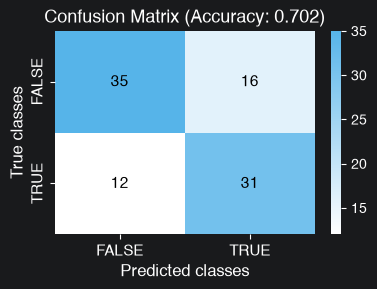

In [6]:
# logistic regression train
lr_params = dict(
    solver='liblinear', 
    class_weight='balanced', 
    # penalty='l2', 
    C=1.04
)


model = LogisticRegression(**lr_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"])

[0.84210526 0.84210526 0.63157895 0.73684211 0.66666667] avg: 0.743859649122807


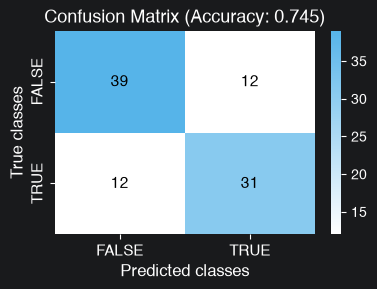

In [7]:
# catboost train
cat_params = dict(
    iterations=250,
    learning_rate=0.02,
    depth=3,
    l2_leaf_reg=8,
    loss_function="Logloss",
    auto_class_weights="Balanced",
    random_seed=random_seed,
    verbose=0
)

model = CatBoostClassifier(**cat_params)

cv = cross_val_score(model, X_train, y_train, cv=5)
print(cv, "avg:", avg(cv))

cv_pred = cross_val_predict(model, X_train, y_train, cv=5)

confusion_matrix_plot(confusion_matrix(y_train, cv_pred),["FALSE", "TRUE"])

# Test

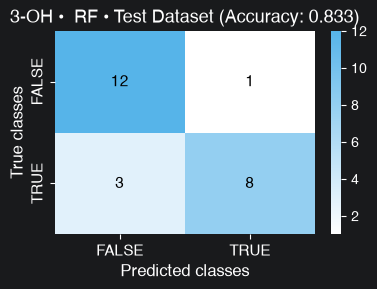

In [8]:
# RF test
model = RandomForestClassifier(**rf_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"], title="3-OH •  RF • Test Dataset")

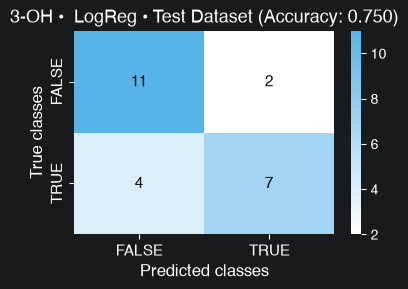

In [9]:
# logistic regression test
model = LogisticRegression(**lr_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"], title="3-OH •  LogReg • Test Dataset")

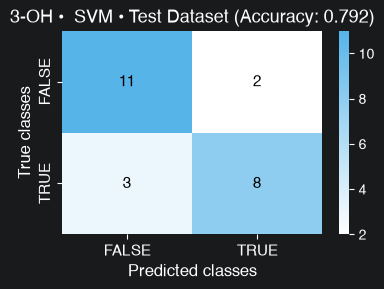

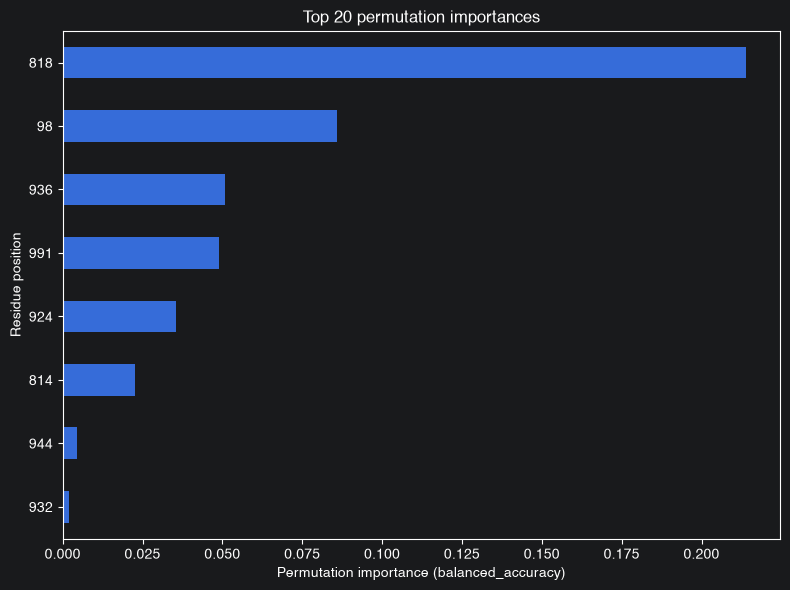

              precision    recall  f1-score   support

       FALSE       0.79      0.85      0.81        13
        TRUE       0.80      0.73      0.76        11

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.79      0.79      0.79        24



In [10]:
# SVM test
model = svm.SVC(**svm_params)


model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(
    confusion_matrix(y_test, model_pred, labels=["FALSE", "TRUE"]),
    ["FALSE", "TRUE"],
    title="3-OH •  SVM • Test Dataset",
    save_path=os.path.join(out_dir, "ml_beta_hydroxylation_cm_test.png"),
    save_as_svg=True,
)
plot_permutation_importances(model, X_test, y_test)

print(classification_report(y_test, model_pred, target_names=["FALSE", "TRUE"]))

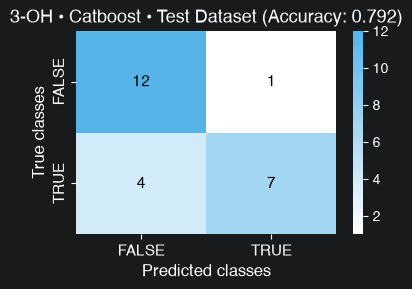

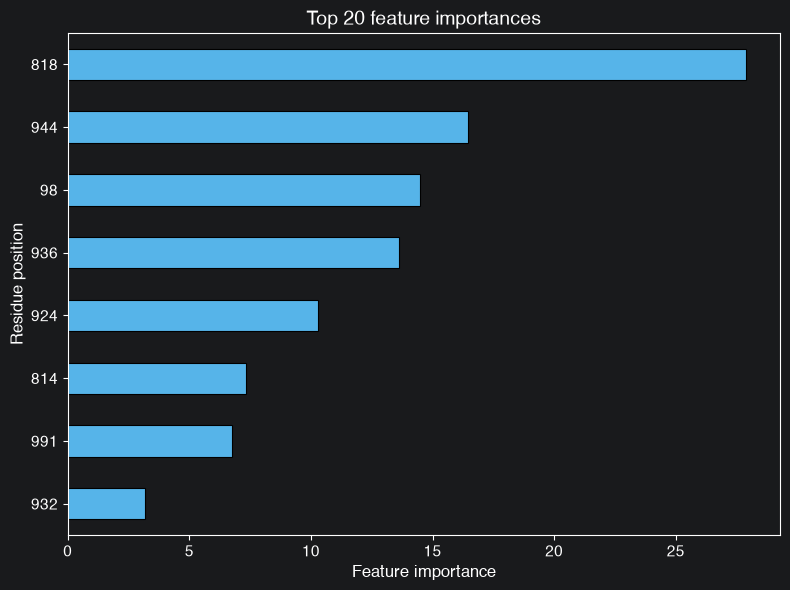

              precision    recall  f1-score   support

       FALSE       0.75      0.92      0.83        13
        TRUE       0.88      0.64      0.74        11

    accuracy                           0.79        24
   macro avg       0.81      0.78      0.78        24
weighted avg       0.81      0.79      0.79        24



In [11]:
# catboost test
model = CatBoostClassifier(**cat_params)

model.fit(X_train, y_train)
model_pred = model.predict(X_test)

confusion_matrix_plot(confusion_matrix(y_test, model_pred), ["FALSE", "TRUE"], title="3-OH • Catboost • Test Dataset")
plot_feature_importances(model, X_test.columns, top_n=20)
print(classification_report(y_test, model_pred, target_names=["FALSE", "TRUE"]))

# Full

[0.79166667 0.75       0.70833333 0.65217391 0.86956522] avg: 0.7543478260869565


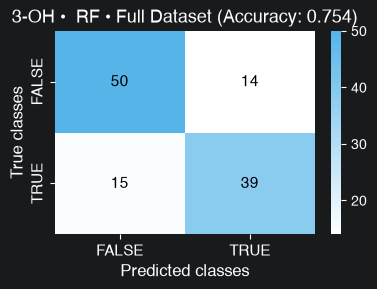

In [12]:
# RF full
model = RandomForestClassifier(**rf_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"], title="3-OH •  RF • Full Dataset")

[0.75       0.75       0.70833333 0.65217391 0.7826087 ] avg: 0.7286231884057971


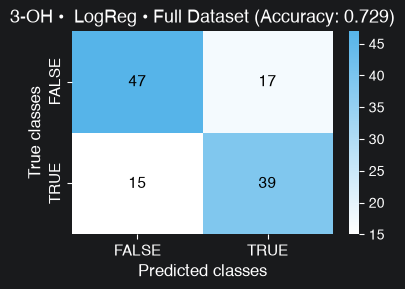

In [13]:
# logistic regression full
model = LogisticRegression(**lr_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"], title="3-OH •  LogReg • Full Dataset")

[0.75       0.79166667 0.79166667 0.65217391 0.86956522] avg: 0.7710144927536231


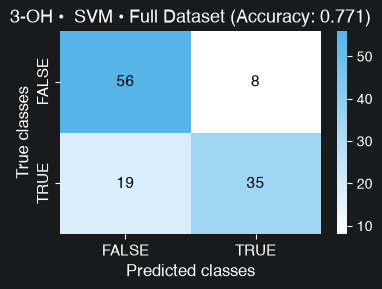

(0.7825942028985508, 0.011950033373449182)

In [14]:
# SVM full
model = svm.SVC(**svm_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"], title="3-OH •  SVM • Full Dataset")

stdev_accuracy(model, X_full, y_full, iterations=100)

[0.79166667 0.83333333 0.75       0.65217391 0.86956522] avg: 0.7793478260869565


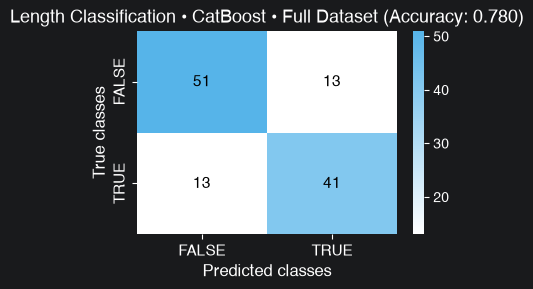

(0.7786195652173913, 0.02545322708540357)

In [15]:
# catboost full
model = CatBoostClassifier(**cat_params)

cv = cross_val_score(model, X_full, y_full, cv=5)
print(cv, 'avg:',  avg(cv))
cv_pred = cross_val_predict(model, X_full, y_full, cv=5)

confusion_matrix_plot(confusion_matrix(y_full, cv_pred, labels=["FALSE", "TRUE"]), ["FALSE", "TRUE"], title="Length Classification • CatBoost • Full Dataset")
stdev_accuracy(model, X_full, y_full, iterations=100)

In [16]:
model = svm.SVC(**svm_params)

model.fit(X_full, y_full)

pickle.dump(model, open(os.path.join(out_dir, "ml_hydroxylation.pkl"), "wb"))